## Przykład: Regulator PID w piecu przemysłowym

In [1]:
import control as ct

class IndustrialFurnaceModel:
    """Model matematyczny pieca przemyslowego (model SOPDT)."""

    def __init__(self):
        # Parametry termodynamiczne
        self.C = 1500.0      # Pojemnosc cieplna [J/K]
        self.R = 0.1         # Opor cieplny [K/W]
        self.tau1 = 12.0     # Dominująca stała czasowa [s]
        self.tau2 = 3.0      # Pomocnicza stała czasowa [s]
        self.theta = 10.0    # Opóźnienie transportowe [s]
        self.K = 0.1         # Wzmocnienie statyczne [K/kW]

        # Warunki otoczenia
        self.T_amb = 25.0    # Temperatura otoczenia [°C]

        # Ograniczenia fizyczne
        self.T_min = 0.0     # Minimalna temperatura [°C]
        self.T_max = 1200.0  # Maksymalna temperatura [°C]
        self.P_max = 50.0    # Maksymalna moc grzałki [kW]

    def create_transfer_function_control(self):
        # Blok 1: opoznienie Pade 2. rzedu
        num_delay, den_delay = ct.pade(self.theta, 2)
        delay_tf = ct.TransferFunction(num_delay, den_delay)

        # Blok 2: obiekt inercyjny drugiego rzedu
        num_plant = [self.K]
        den_plant = [self.tau1 * self.tau2, self.tau1 + self.tau2, 1.0]
        plant_tf = ct.TransferFunction(num_plant, den_plant)

        # Polaczenie szeregowe: G(s) = G_delay * G_plant
        return ct.series(delay_tf, plant_tf)

In [2]:
def pid_controller(K_p, Ki, Kd, N=20):
    s = ct.tf('s')
    tau_f = Kd / N
    return K_p + Ki / s + (Kd * s) / (tau_f * s + 1)

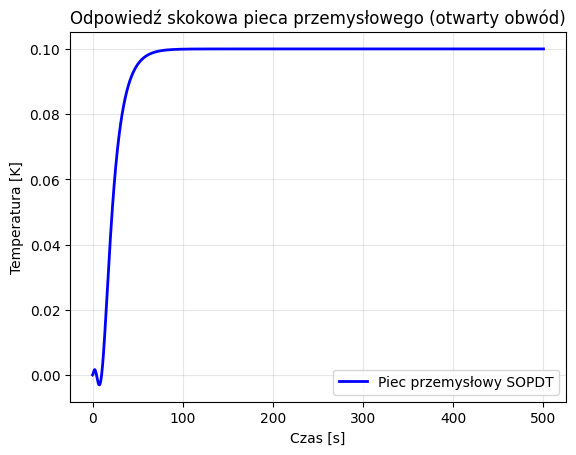

In [3]:
import matplotlib.pyplot as plt
import numpy as np

furnace = IndustrialFurnaceModel()
G = furnace.create_transfer_function_control()

t = np.linspace(0, 500, 2000)
t_step, y_step = ct.step_response(G, T=t)

plt.plot(t_step, y_step, 'b-', linewidth=2)
plt.xlabel('Czas [s]')
plt.ylabel('Temperatura [K]')
plt.title('Odpowiedź skokowa pieca przemysłowego (otwarty obwód)')
plt.grid(True, alpha=0.3)
plt.legend(['Piec przemysłowy SOPDT'])